<a href="https://colab.research.google.com/github/Aaron-GMM/disciplina-PLN/blob/main/atividade_de_pre_processamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

In [6]:
nltk.download('punkt')
nltk.download('stopwords')
!python -m spacy download pt_core_news_sm
nlp = spacy.load("pt_core_news_sm")
stop_words_nltk = set(nltk.corpus.stopwords.words('portuguese'))

import kagglehub
import os

dataset_path =  kagglehub.dataset_download("olistbr/brazilian-ecommerce")
df = pd.read_csv(os.path.join(dataset_path, 'olist_order_reviews_dataset.csv'))

df = df[['review_comment_message', 'review_score']].dropna().copy()

df = df[df['review_score'] != 3]
df['class'] = df['review_score'].apply(lambda x: 'Positivo' if x > 3 else 'Negativo')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 75.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.


In [7]:
def preprocess_text(text, remove_stopwords=True):
    text = str(text).lower() # Conversão para minúsculas
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remoção de URLs
    text = re.sub(r'\d+', '', text) # Remoção de números
    text = re.sub(r'[^\w\s]', '', text) # Remoção de pontuação

    doc = nlp(text)

    tokens_processados = []
    for token in doc:
        if remove_stopwords and token.text in stop_words_nltk:
            continue

        # 5. Lematização
        if token.lemma_.strip() != "":
            tokens_processados.append(token.lemma_)

    return tokens_processados

df_sample = df.sample(5000, random_state=42).copy()

df_sample['tokens_raw'] = df_sample['review_comment_message'].apply(lambda x: str(x).lower().split())

df_sample['tokens_with_stopwords'] = df_sample['review_comment_message'].apply(lambda x: preprocess_text(x, remove_stopwords=False))

df_sample['tokens_clean'] = df_sample['review_comment_message'].apply(lambda x: preprocess_text(x, remove_stopwords=True))

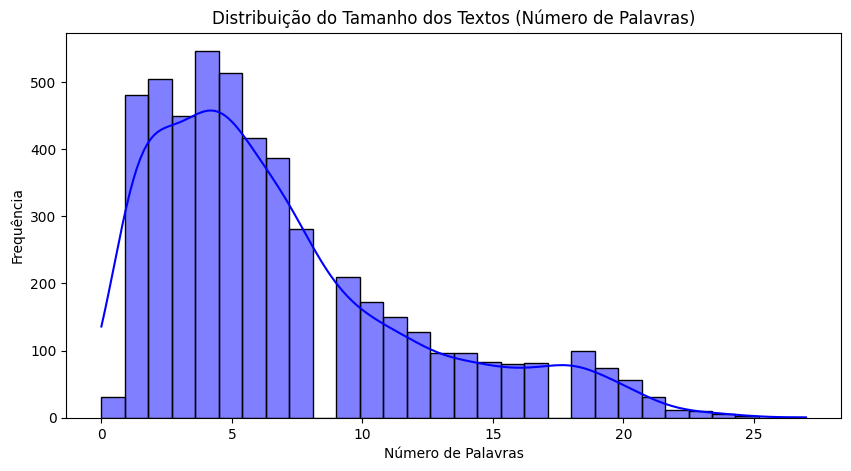

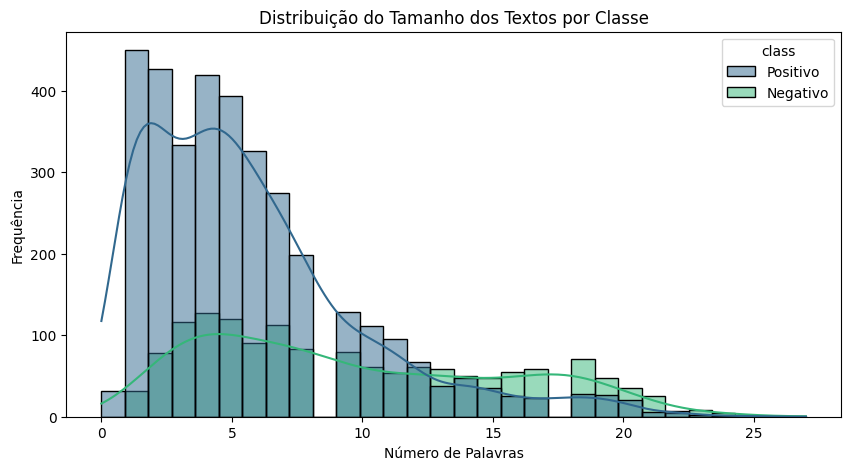

In [8]:
df_sample['tamanho_texto'] = df_sample['tokens_clean'].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(df_sample['tamanho_texto'], bins=30, kde=True, color='blue')
plt.title('Distribuição do Tamanho dos Textos (Número de Palavras)')
plt.xlabel('Número de Palavras')
plt.ylabel('Frequência')
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(data=df_sample, x='tamanho_texto', hue='class', bins=30, kde=True, palette='viridis')
plt.title('Distribuição do Tamanho dos Textos por Classe')
plt.xlabel('Número de Palavras')
plt.ylabel('Frequência')
plt.show()

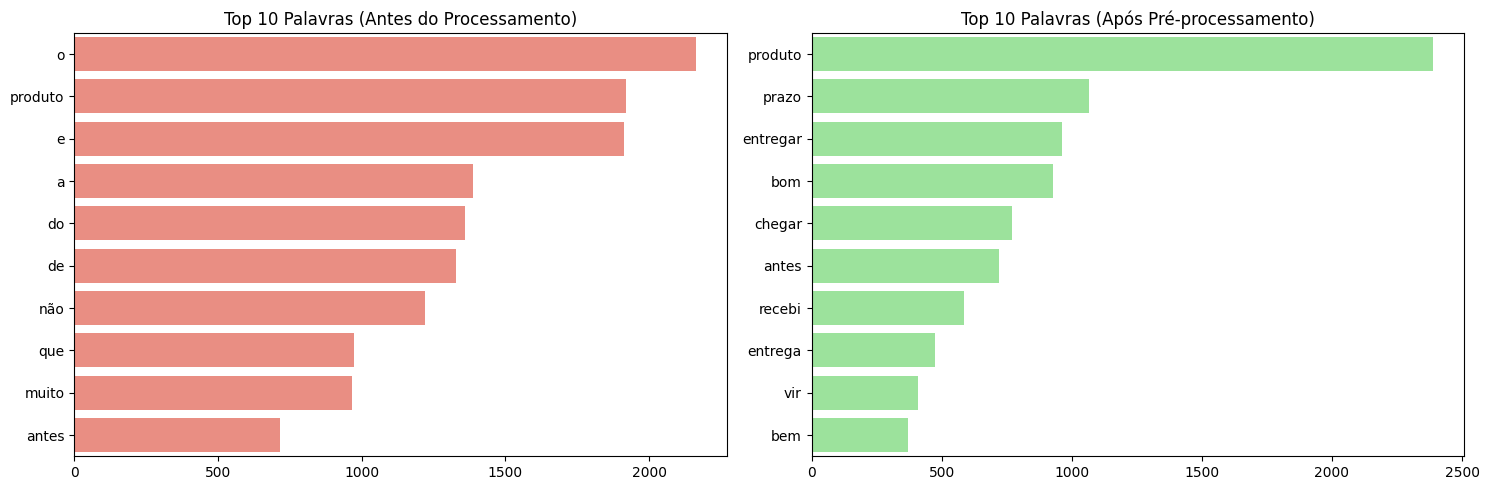

In [9]:
def get_top_n_words(token_list_series, n=10):
    all_words = [word for tokens in token_list_series for word in tokens]
    return Counter(all_words).most_common(n)

top_10_raw = get_top_n_words(df_sample['tokens_raw'])
top_10_clean = get_top_n_words(df_sample['tokens_clean'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

words_raw, counts_raw = zip(*top_10_raw)
sns.barplot(x=list(counts_raw), y=list(words_raw), ax=axes[0], color='salmon')
axes[0].set_title('Top 10 Palavras (Antes do Processamento)')

words_clean, counts_clean = zip(*top_10_clean)
sns.barplot(x=list(counts_clean), y=list(words_clean), ax=axes[1], color='lightgreen')
axes[1].set_title('Top 10 Palavras (Após Pré-processamento)')

plt.tight_layout()
plt.show()

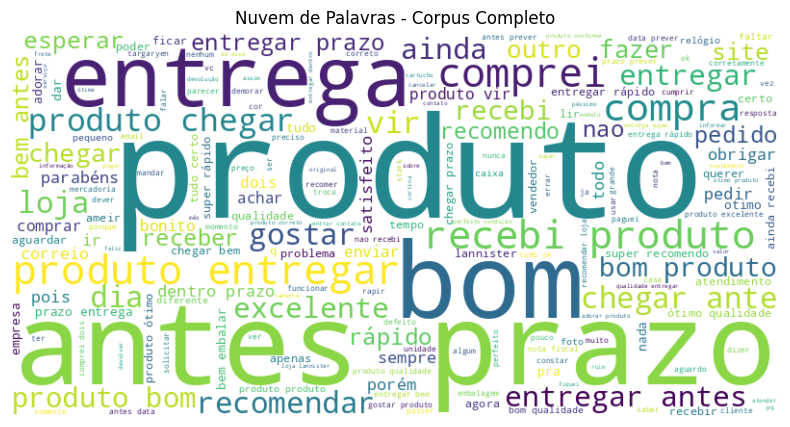

In [10]:
todas_palavras_limpas = " ".join([word for tokens in df_sample['tokens_clean'] for word in tokens])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(todas_palavras_limpas)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de Palavras - Corpus Completo')
plt.show()

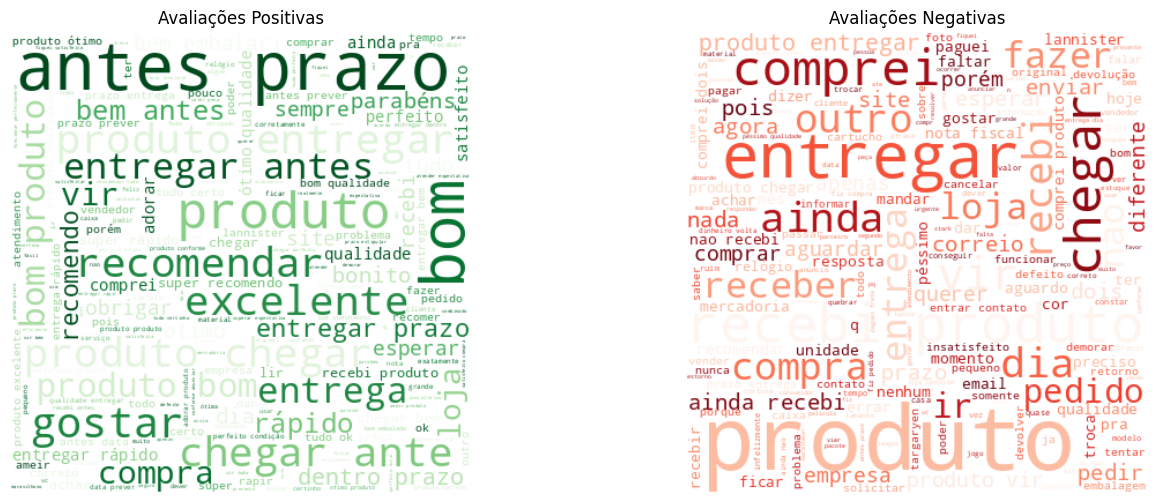

In [11]:
# Separando os tokens por classe
tokens_positivos = df_sample[df_sample['class'] == 'Positivo']['tokens_clean']
tokens_negativos = df_sample[df_sample['class'] == 'Negativo']['tokens_clean']

texto_positivo = " ".join([word for tokens in tokens_positivos for word in tokens])
texto_negativo = " ".join([word for tokens in tokens_negativos for word in tokens])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


wc_pos = WordCloud(width=400, height=400, background_color='white', colormap='Greens').generate(texto_positivo)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Avaliações Positivas')
axes[0].axis('off')


wc_neg = WordCloud(width=400, height=400, background_color='white', colormap='Reds').generate(texto_negativo)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Avaliações Negativas')
axes[1].axis('off')

plt.show()